# Processed Data Playground
Create plots, visualize distributions and understand cohort selection

In [16]:
import pandas as pd
import os
import sys
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Notebook is in notebooks/, so repo root is parent
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

In [17]:
from src.models.xgboost import load_data_files

# Get repo root relative to the current notebook
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Load static preprocessing config
config_path = os.path.join(repo_root, "configs", "xgboost_params.json")
with open(config_path, "r") as f:
    config = json.load(f)

# Set input and output directories
in_dir = os.path.join(repo_root, config["paths"]["in_dir"])


ed_vitals, clinical_encounters, ecg_records = load_data_files(in_dir, config)

In [18]:
print(ed_vitals.shape)
ed_vitals.head()

(1225239, 10)


,subject_id,stay_id,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp,chartdate
0,17195991,38649090,2110-01-11 21:45:00,NaN,141.0,24.0,94.0,NaN,NaN,2110-01-11
1,17195991,38649090,2110-01-11 21:50:00,NaN,123.0,24.0,91.0,151.0,120.0,2110-01-11
2,17195991,38649090,2110-01-11 22:00:00,NaN,133.0,23.0,99.0,180.0,86.0,2110-01-11
3,17195991,38649090,2110-01-11 22:07:00,NaN,164.0,24.0,99.0,198.0,116.0,2110-01-11
4,17195991,38649090,2110-01-11 22:23:00,NaN,130.0,16.0,100.0,235.0,126.0,2110-01-11


In [19]:
print(clinical_encounters.shape)
clinical_encounters.head()

(494231, 19)


,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,death_time,icu_stay_id,icu_intime,icu_outtime,icu_count,diagnosis,icd_codes,diagnosis_labels,is_cardiovascular
0,10000032,22595853.0,33258284.0,2180-05-06 19:17:00,2180-05-06 23:30:00,2180-05-06 22:23:00,2180-05-07 17:15:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,"['Portal hypertension', 'Other ascites', 'Cirr...","['572.3', '789.59', '571.5', '070.70', '496', ...",[],False
1,10000032,22841357.0,38112554.0,2180-06-26 15:54:00,2180-06-26 21:31:00,2180-06-26 18:27:00,2180-06-27 18:49:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,['Unspecified viral hepatitis C with hepatic c...,"['070.71', '789.59', '287.5', '276.1', '496', ...",[],False
2,10000032,25742920.0,35968195.0,2180-08-05 20:58:00,2180-08-06 01:44:00,2180-08-05 23:44:00,2180-08-07 17:50:00,WHITE,F,52.0,2180-09-09 00:00:00,NaN,NaN,NaN,NaN,['Chronic hepatitis C without mention of hepat...,"['070.54', '789.59', 'V46.2', '571.5', '276.7'...",[],False
3,10000032,29079034.0,39399961.0,2180-07-23 05:54:00,2180-07-23 14:00:00,2180-07-23 12:35:00,2180-07-25 17:55:00,WHITE,F,52.0,2180-09-09 00:00:00,[39553978],['2180-07-23 14:00:00'],['2180-07-23 23:50:47'],1.0,"['Other iatrogenic hypotension', 'Chronic hepa...","['458.29', '070.44', '799.4', '276.1', '789.59...",[],False
4,10000117,27988844.0,33176849.0,2183-09-18 08:41:00,2183-09-18 20:20:00,2183-09-18 18:10:00,2183-09-21 16:30:00,WHITE,F,48.0,NaN,NaN,NaN,NaN,NaN,['Unspecified intracapsular fracture of left f...,"['S72.012A', 'W01.0XXA', 'Y93.K1', 'Y92.480', ...",['valvular_endocardial_disease'],True


In [70]:
ed_encounters = clinical_encounters[clinical_encounters["ed_stay_id"].notna()]
print("Number of ed encounters:", ed_encounters.shape[0])
print("Number of unique ED patients:", ed_encounters["subject_id"].nunique())
print("Number of unique ED patients:", ed_encounters["ed_stay_id"].nunique())


hosp_encounters = clinical_encounters[clinical_encounters["hadm_id"].notna()]
print("Number of hospital encounters:", hosp_encounters.shape[0])
print("Number of unique hospital patients:", hosp_encounters["subject_id"].nunique())


Number of ed encounters: 265702
Number of unique ED patients: 102125
Number of unique ED patients: 265702
Number of hospital encounters: 360268
Number of unique hospital patients: 124947


In [71]:
ed_encounters['race'].value_counts()

race
WHITE                                        139572
BLACK/AFRICAN AMERICAN                        54604
OTHER                                         10730
HISPANIC/LATINO - PUERTO RICAN                10127
WHITE - OTHER EUROPEAN                         6046
HISPANIC/LATINO - DOMINICAN                    5642
BLACK/CAPE VERDEAN                             5518
WHITE - RUSSIAN                                4785
ASIAN - CHINESE                                3950
ASIAN                                          2942
BLACK/AFRICAN                                  2710
UNKNOWN                                        2610
BLACK/CARIBBEAN ISLAND                         2409
HISPANIC OR LATINO                             2023
HISPANIC/LATINO - GUATEMALAN                   1387
PORTUGUESE                                      940
HISPANIC/LATINO - SALVADORAN                    931
WHITE - EASTERN EUROPEAN                        886
ASIAN - SOUTH EAST ASIAN                        846
HISPANI

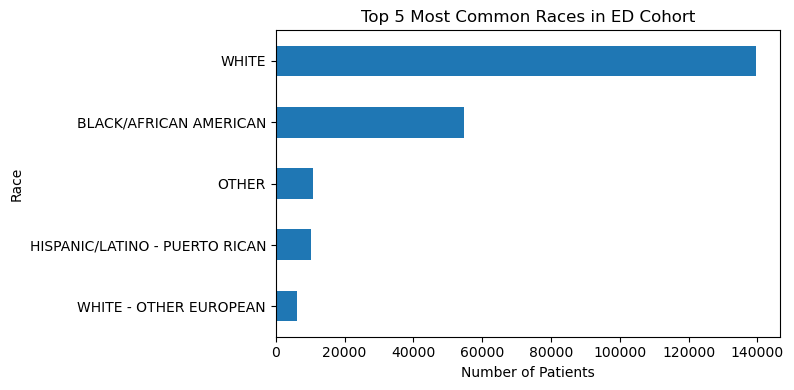

In [72]:
race_counts = ed_encounters['race'].value_counts().head(5)

fig, ax = plt.subplots(figsize=(8, 4))
race_counts.plot(kind='barh', ax=ax)

ax.set_xlabel("Number of Patients")
ax.set_ylabel("Race")
ax.set_title("Top 5 Most Common Races in ED Cohort")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

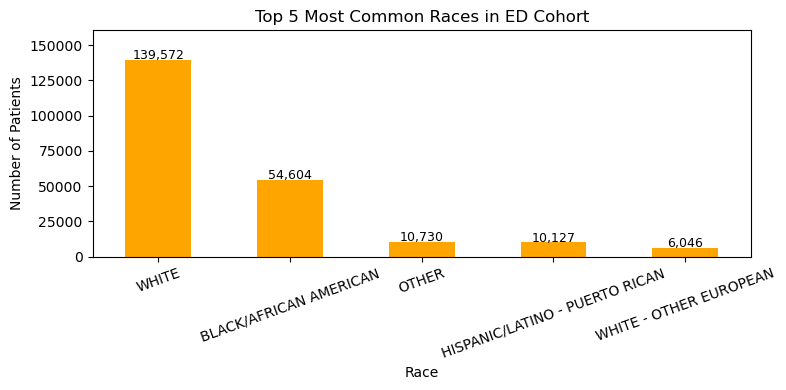

In [73]:
race_counts = ed_encounters['race'].value_counts().head(5)

fig, ax = plt.subplots(figsize=(8, 4))
race_counts.plot(kind='bar', ax=ax, color='orange')

ax.set_xlabel("Race")
ax.set_ylabel("Number of Patients")
ax.set_title("Top 5 Most Common Races in ED Cohort")
ax.tick_params(axis='x', rotation=20)
ax.set_ylim(0, race_counts.max() * 1.15)  # 15% padding on top

for i, val in enumerate(race_counts.values):
    ax.text(i, val + 500, f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

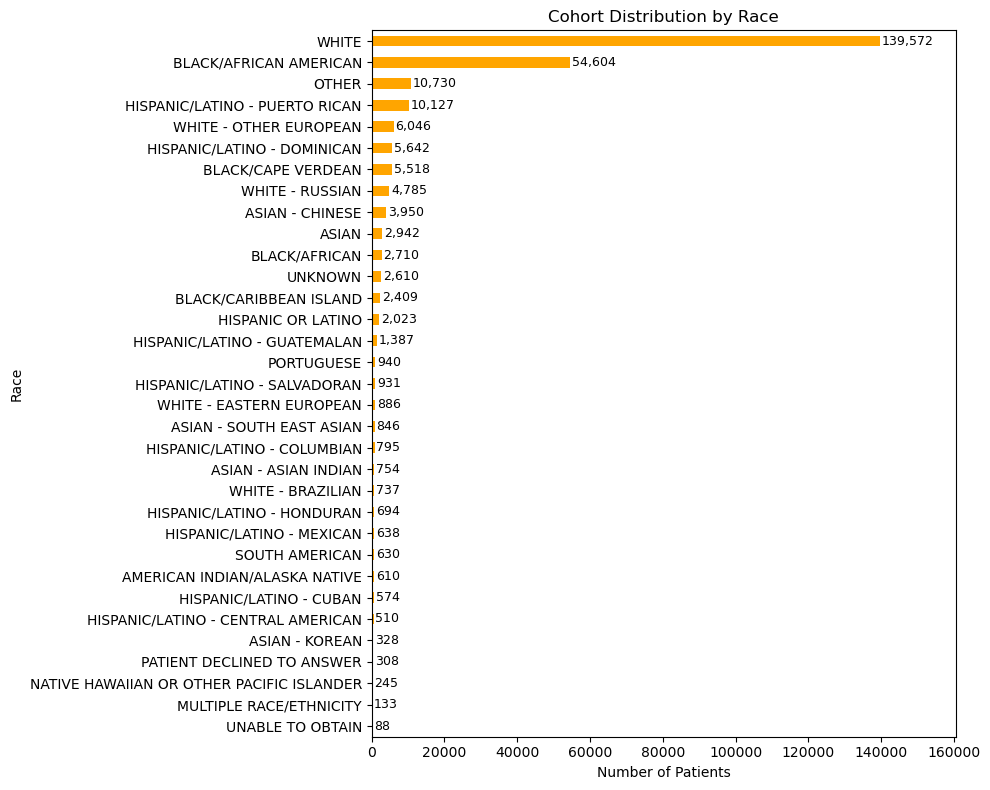

In [74]:
race_counts = ed_encounters['race'].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
race_counts.plot(kind='barh', ax=ax, color='orange')

ax.set_xlabel("Number of Patients")
ax.set_ylabel("Race")
ax.set_title("Cohort Distribution by Race")
ax.invert_yaxis()
ax.set_xlim(0, race_counts.max() * 1.15)

for i, val in enumerate(race_counts.values):
    ax.text(val + 500, i, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [75]:
ed_encounters['race'].nunique()

33

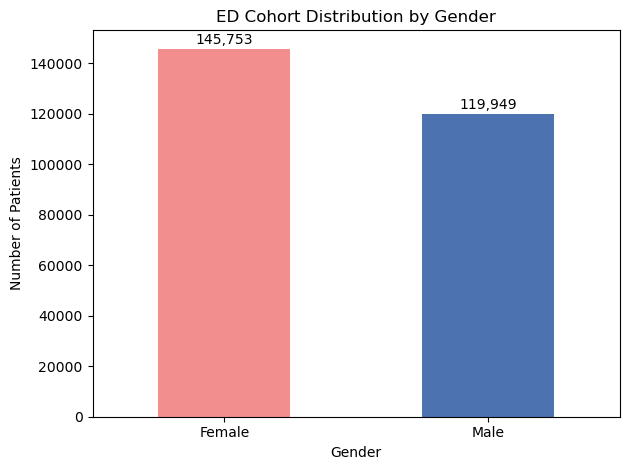

In [76]:
gender_counts = ed_encounters['gender'].value_counts()

gender_counts = gender_counts.rename(index={'F': 'Female', 'M': 'Male'})

colors = ['#F28E8E', '#4C72B0']  # coral pink (Female), soft blue (Male)

plt.figure()
ax = gender_counts.plot(kind='bar', color=colors)

plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.title("ED Cohort Distribution by Gender")
plt.xticks(rotation=0)

# Add values on top of bars
for i, v in enumerate(gender_counts):
    ax.text(i, v + 2000, f"{v:,}", ha='center')

plt.tight_layout()
plt.show()

In [77]:
ed_encounters['gender'].value_counts()

gender
F    145753
M    119949
Name: count, dtype: int64

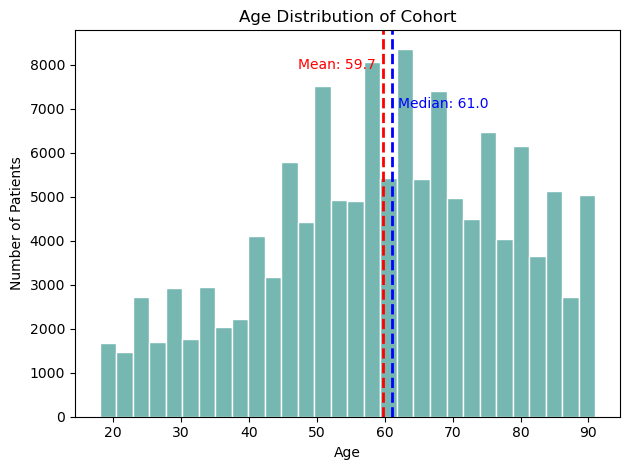

In [78]:
ages = pd.to_numeric(ed_encounters['anchor_age'], errors='coerce').dropna()

plt.figure()
ax = plt.gca()

# Histogram with a softer teal color
ax.hist(ages, bins=30, color='#76B7B2', edgecolor='white')

# Mean age line
mean_age = ages.mean()
ax.axvline(mean_age, linestyle='--', linewidth=2, color='red')

median_age = ages.median()
ax.axvline(median_age, linestyle='--', linewidth=2, color='blue')

# Annotate the mean
ax.text(mean_age - 1, ax.get_ylim()[1]*0.9, f"Mean: {mean_age:.1f}", color='red', ha='right')

# Annotate the median
ax.text(median_age + 1, ax.get_ylim()[1]*0.8, f"Median: {median_age:.1f}", color='blue')


ax.set_xlabel("Age")
ax.set_ylabel("Number of Patients")
ax.set_title("Age Distribution of Cohort")

plt.tight_layout()
plt.show()

In [79]:
ed_encounters['anchor_age'].value_counts()

anchor_age
91.0    4266
64.0    2896
57.0    2824
60.0    2768
52.0    2752
        ... 
89.0     784
22.0     754
21.0     710
19.0     492
18.0     334
Name: count, Length: 73, dtype: int64

In [25]:
print(ecg_records.shape)
ecg_records.head()

(403121, 26)


,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,...,rr_interval,p_onset,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis,full_report
0,16598616,40000035,40000035,2126-04-01 19:32:00,files/p1659/p16598616/s40000035/40000035,26101986.0,32731561.0,NaN,0,1,...,800,40,162,194,286,576,48,14,33,"['abnormal_ecg', 'infarct_pattern', 'normal_ec..."
1,18370366,40000084,40000084,2179-08-30 11:58:00,files/p1837/p18370366/s40000084/40000084,NaN,37736561.0,NaN,0,1,...,1176,40,140,202,280,602,59,56,45,"['normal_ecg', 'sinus_bradycardia', 'technical..."
2,12576058,40000115,40000115,2163-04-17 16:45:00,files/p1257/p12576058/s40000115/40000115,NaN,36567247.0,NaN,0,1,...,779,305,29999,503,627,971,0,83,50,['unspecified_ecg']
3,14691089,40000143,40000143,2175-07-21 01:01:00,files/p1469/p14691089/s40000143/40000143,23760732.0,38981935.0,NaN,0,1,...,690,348,29999,499,591,890,26,-49,59,"['infarct_pattern', 'sinus_rhythm']"
4,16089780,40000152,40000152,2137-01-29 19:08:00,files/p1608/p16089780/s40000152/40000152,NaN,31326149.0,NaN,0,1,...,645,40,124,176,268,536,51,29,63,"['borderline_ecg', 'sinus_rhythm', 'st_t_abnor..."


In [81]:
ecg_records[ecg_records['in_ed']==1].shape

(158284, 26)

In [26]:
pd.read_csv('../data/raw/machine_measurements.csv').shape

/var/folders/bn/28hly9dd0z36556zl0gx44v80000gn/T/ipykernel_73541/1951756246.py:1: DtypeWarning: Columns (16,17,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv('../data/raw/machine_measurements.csv').shape


(800035, 33)

In [27]:
ecg_records[ecg_records['ed_stay_id'].notna()].shape

(241180, 26)